Untuk mengisi waktu luang, anda suka mencoba berbagai games yang tersedia di Playstore. Suatu ketika sebelum
mendownload suatu games, anda membaca review-review yang terdapat di Playstore mengenai games tersebut
beserta ratingnya. Anda berpikir jika dapat membangun model prediksi rating, model ini dapat digunakan pihak
games untuk memprediksi konten dari sumber lain. Maka anda berinisiatif untuk

## No. 1

Mengumpulkan data review games dengan tema yang anda suka dengan cara
scrapping sebanyak 2000 data dengan berbagai nilai rating. Anda juga memutuskan untuk mengumpulkan data
review dalam bahasa Inggris.

In [ ]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.8 MB/s eta 0:00:00


Scrapping rating game Tetris dari Google Play Store

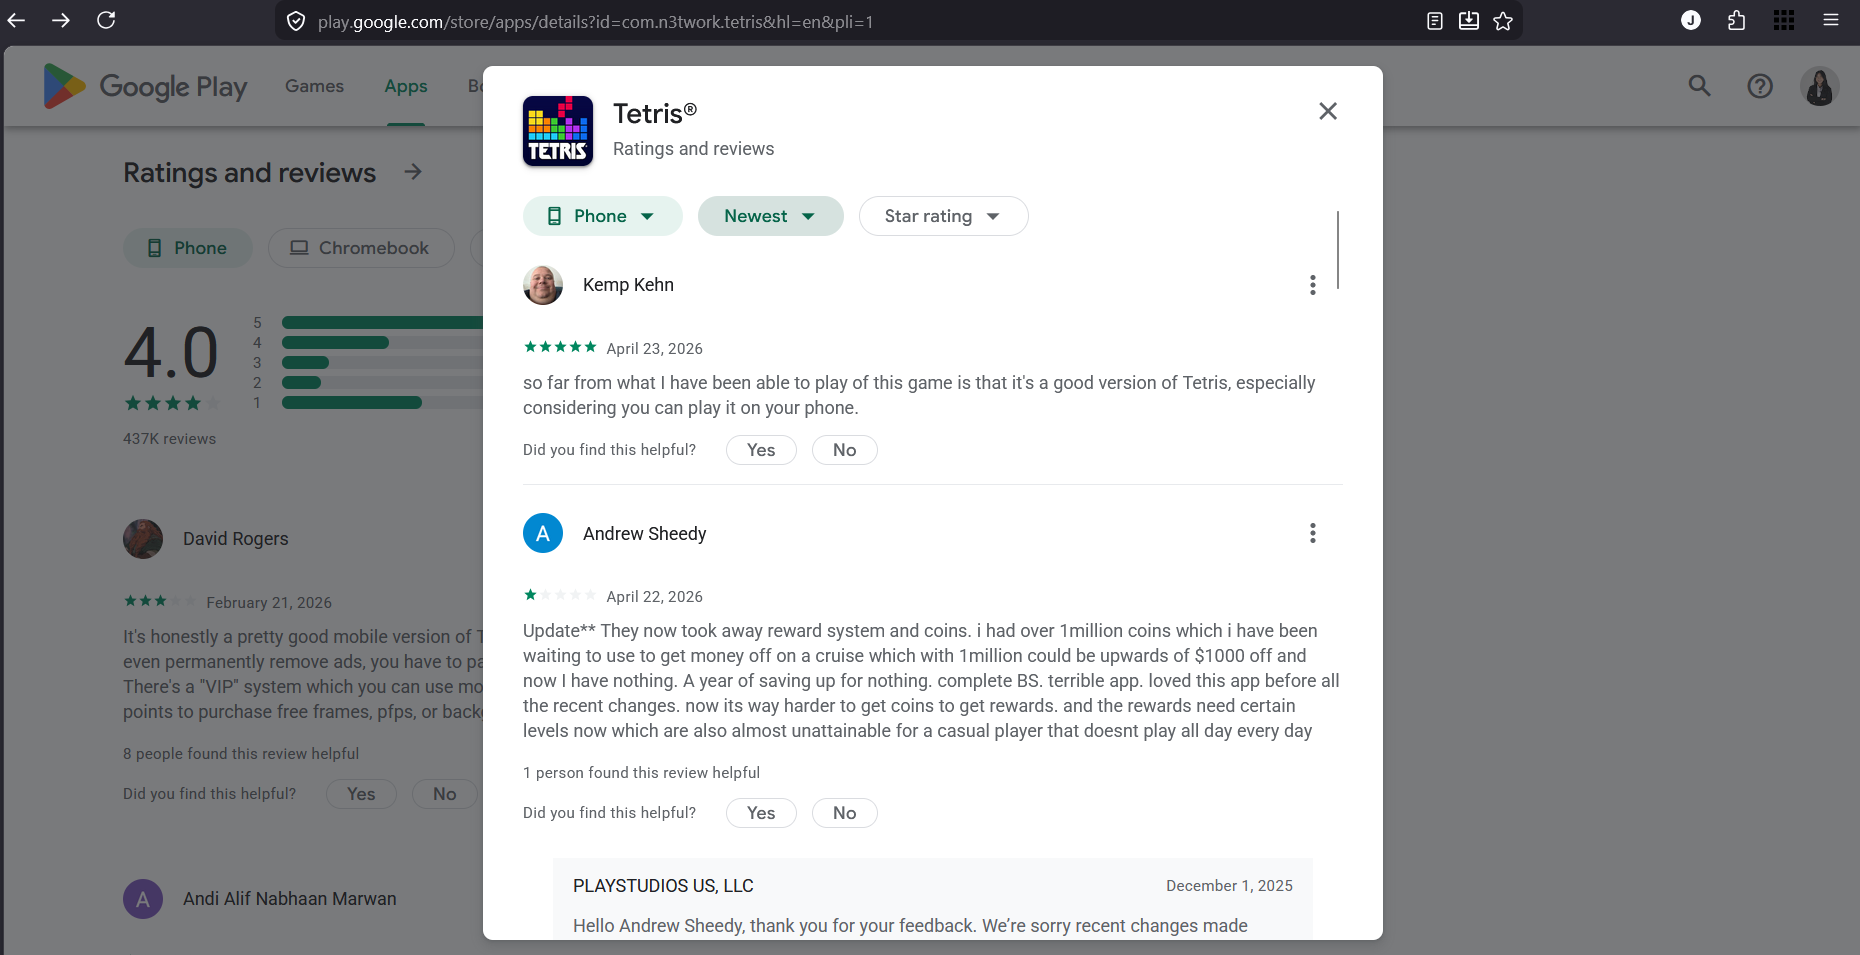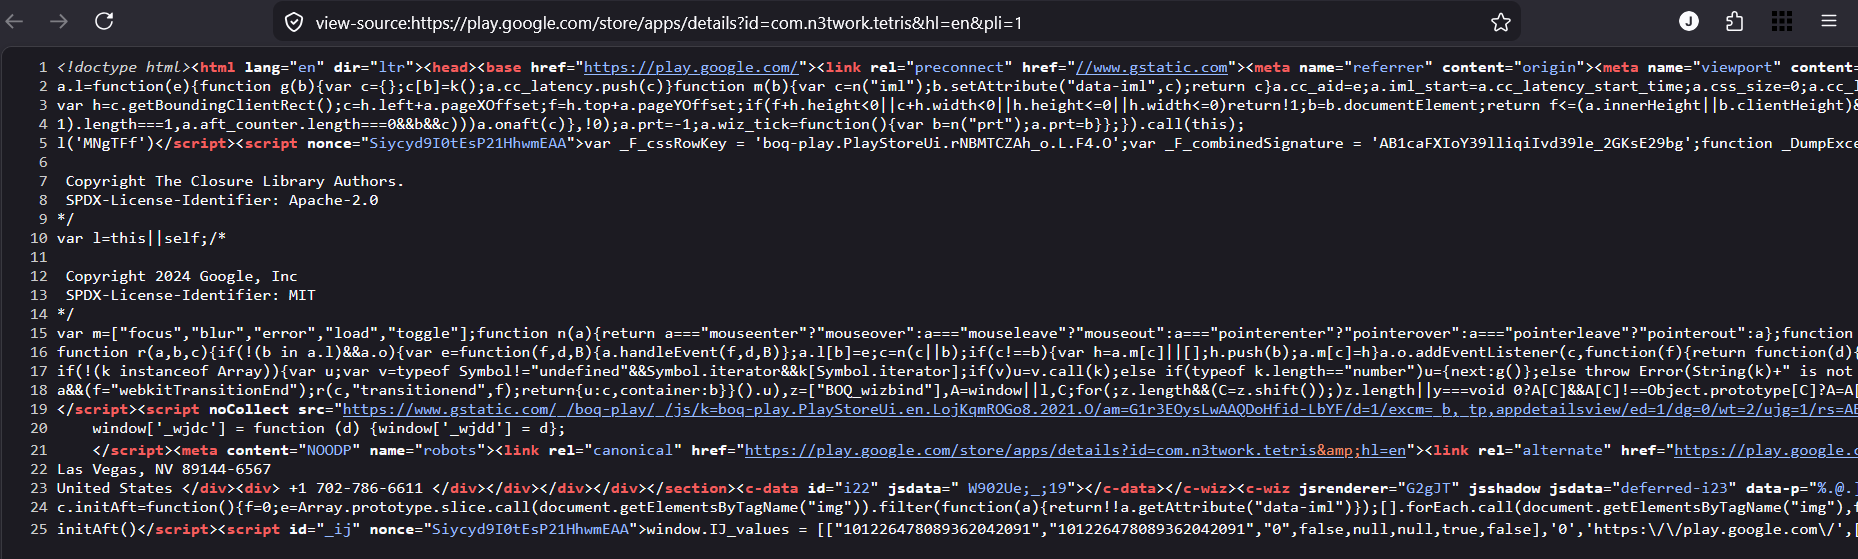

Terlihat bahwa App ID berupa com.n3twork.tetris

In [ ]:
import pandas as pd
from google_play_scraper import reviews, Sort

def scrape_reviews(app_id, total=2000):
    all_reviews = []
    continuation_token = None

    while len(all_reviews) < total:
        result, continuation_token = reviews(
            app_id,
            lang='en',
            country='us',
            sort=Sort.NEWEST,
            count=200,
            continuation_token=continuation_token
        )
        all_reviews.extend(result)

        if continuation_token is None:
            break

    df = pd.DataFrame(all_reviews)[['content', 'score']]
    df.columns = ['review', 'rating']
    return df.head(total)

df = scrape_reviews('com.n3twork.tetris', 2000)
df.to_csv("tetris_reviews.csv", index=False)
df.head()

,review,rating
0,ads slop HOLY,1
1,Where are the NEW LEVELS? Orig Review: So v.ma...,1
2,so far from what I have been able to play of t...,5
3,Update** They now took away reward system and ...,1
4,Forced Add after every single level. Annoying,1


Dari hasil df.head() juga terlihat bahwa data sudah sesuai dengan sumber review yang diurutkan berdasarkan urutan waktu terbaru

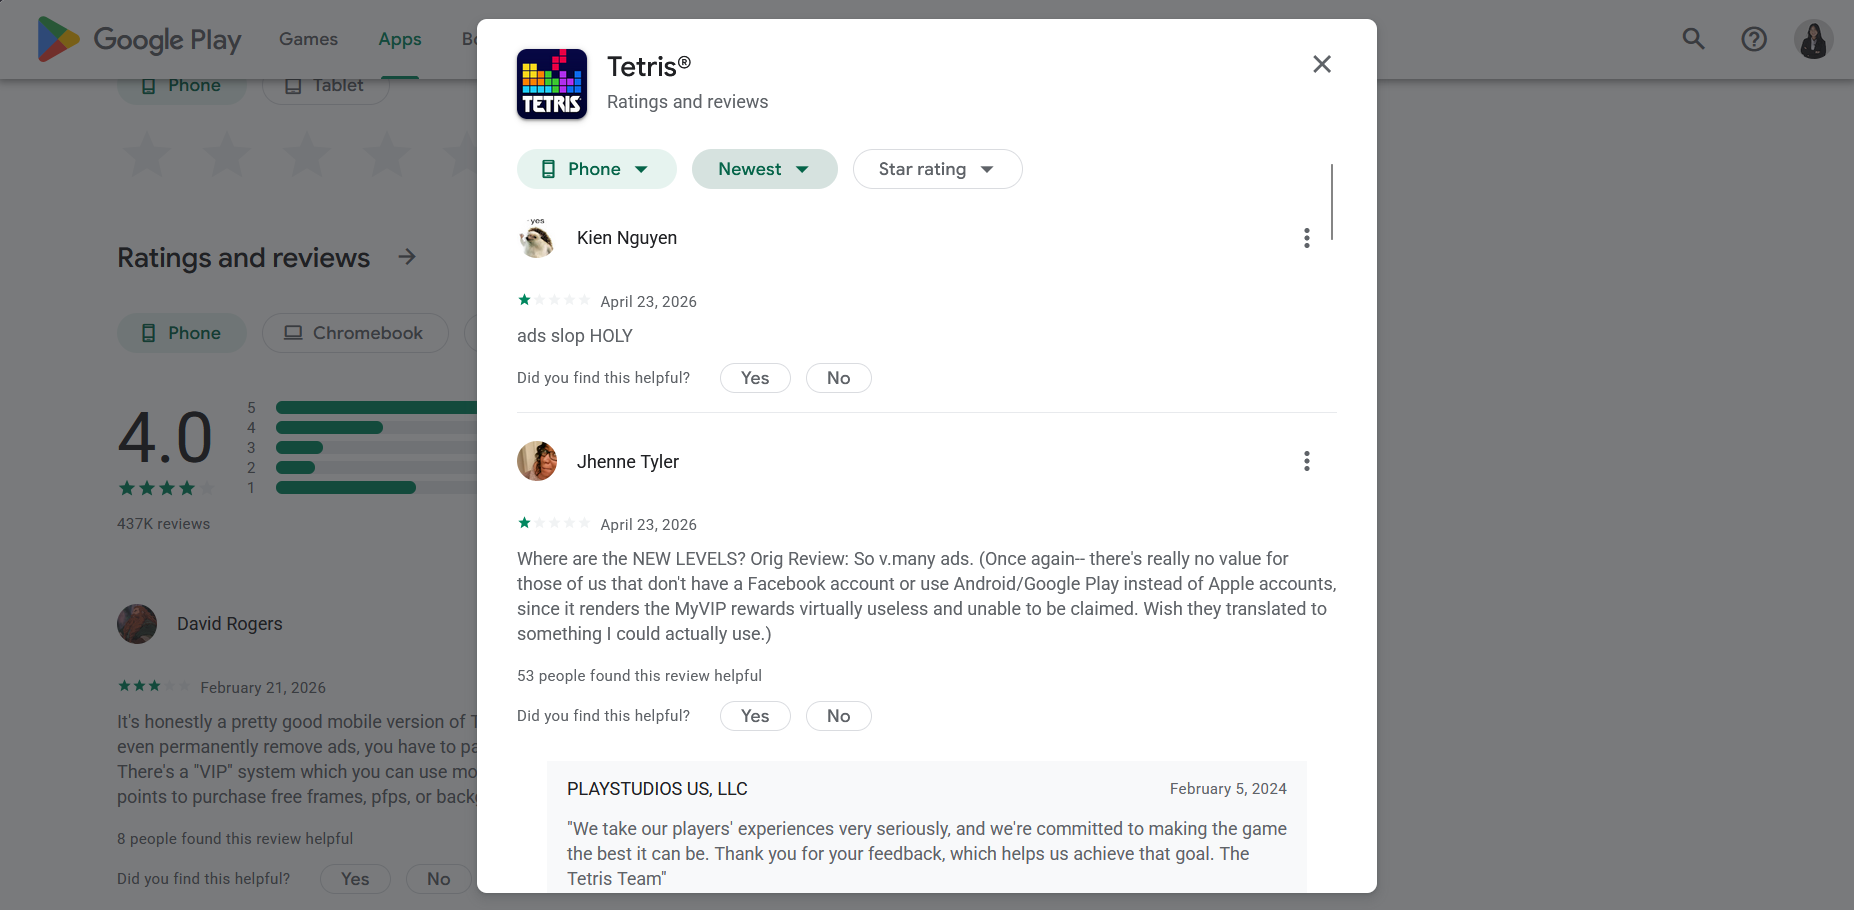

Berdasarkan hasil tampilan beberapa data, ditemukan bahwa teks review masih mengandung banyak kata tidak baku seperti slang, singkatan, serta variasi penulisan informal yang umum digunakan dalam ulasan pengguna. Hal ini menunjukkan bahwa data teks dari review memiliki tingkat noise yang tinggi, yang menjadi tantangan utama dalam proses text mining.

## No. 2

Anda ingin mengenal data yang anda scrapping, maka anda melakukan exploratory
terhadap data untuk melihat kata-kata yang dominan disetiap rating dan memeriksa apakah kata-kata yang tidak
sesuai dengan standar bahasa punya frekuensi yang besar

### Distribusi Rating

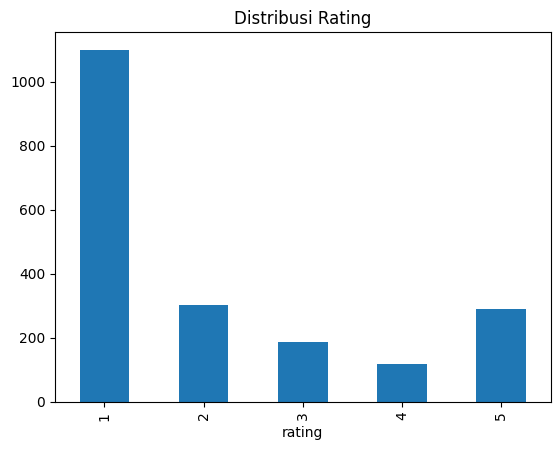

In [ ]:
import matplotlib.pyplot as plt
df['rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribusi Rating")
plt.show()

Terlihat bahwa berdasarkan 2000 rating terbaru mayoritas menilai bintang 1, dan terlihat juga bahwa data cenderung imbalance.

### Distribusi Panjang Review berdasarkan Jumlah Karakter

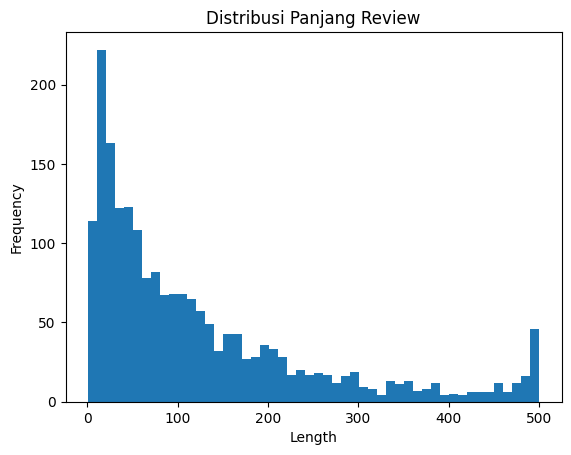

In [ ]:
df['length'] = df['review'].apply(len)

import matplotlib.pyplot as plt

plt.hist(df['length'], bins=50)
plt.title("Distribusi Panjang Review")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

Terlihat bahwa mayoritas review ada di sekitar 20-120 karakter, sehingga data cenderung right-skewed. Namun tetap ada sebagian kecil user yang menulis sangat panjang dengan jumlah karakter mendekati 500.

### Rata-rata Panjang Review per Kelas Rating

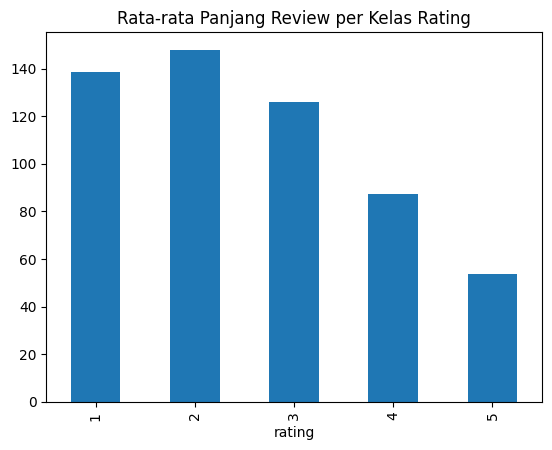

In [ ]:
df.groupby('rating')['length'].mean().plot(kind='bar')
plt.title("Rata-rata Panjang Review per Kelas Rating")
plt.show()

Dari plot tersebut terlihat bahwa semakin rendah rating, semakin panjang review yang diberikan pengguna. Hal ini dapat menunjukkan bahwa user memberikan penjelasan yang lebih detail ketika menyampaikan complain atau ketidakpuasan. Sebaliknya, rating yang lebih tinggi umumnya disertai dengan review yang lebih singkat, yang mencerminkan ekspresi kepuasan secara sederhana.

### Analisis Kata Tidak Standar

In [ ]:
import nltk
nltk.download('words')
from nltk.corpus import words
from collections import Counter

english_vocab = set(words.words())

all_words = " ".join(df['review']).lower().split()
word_counts = Counter(all_words)

non_standard_words = {
    word: count for word, count in word_counts.items()
    if word not in english_vocab
}

sorted(non_standard_words.items(), key=lambda x: x[1], reverse=True)[:20]

[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


[('ads', 723),
 ('tetris', 387),
 ("it's", 252),
 ('app', 243),
 ('ads.', 203),
 ('game.', 168),
 ("don't", 144),
 ("can't", 139),
 ('playing', 129),
 ('offline', 115),
 ('has', 114),
 ('tetris.', 98),
 ('ads,', 95),
 ('game,', 90),
 ("doesn't", 90),
 ('it.', 84),
 ('levels', 81),
 ('games', 79),
 ('tetris,', 73),
 ("i'm", 70)]

Ditemukan banyak kata tidak standar akibat variasi tanda baca dan kontraksi, yang menyebabkan inkonsistensi dalam data. Hal ini menunjukkan perlunya preprocessing untuk membersihkan dan menormalkan teks sebelum digunakan dalam pemodelan.

### Distribusi Frekuensi Kata

In [ ]:
words = " ".join(df['review']).split()
Counter(words).most_common(20)

[('the', 1846),
 ('to', 1517),
 ('and', 1020),
 ('I', 925),
 ('a', 913),
 ('game', 754),
 ('it', 724),
 ('ads', 660),
 ('you', 637),
 ('is', 625),
 ('of', 605),
 ('this', 474),
 ('for', 454),
 ('play', 404),
 ('but', 391),
 ('that', 356),
 ('not', 310),
 ('have', 306),
 ('are', 299),
 ('in', 285)]

Dari hasil word frequency count tersebut terlihat bahwa masih terapat banyak stopwords yang tidak memberikan informasi penting, sehingga perlu dilakukan preprocessing terlebih dahulu.

### Perbandingan Panjang Review Rating 1 VS Rating 5

In [ ]:
print("Sample Rating 1: \n")
for text in df[df['rating']==1]['review'].sample(5):
    print("-", text)

print("\nSample Rating 5: \n")
for text in df[df['rating']==5]['review'].sample(5):
    print("-", text)

Sample Rating 1: 

- candy crush music begins playing Everytime I try to play a game even tho I have the sound and music setting off. have tried uninstalling and re installing with no luck. this only started after excessive candy crush ads began and I don't have candy crush even installed on this phone.
- Terrible experience. Used to be good before the relentless ads and when you could play offline
- as a millennial. I find this version an atrocity on the simplicity of the classic tetris.
- not tetris
- Started out working well. But now, when I open the app to play the game, it sits there on the first loading screen continually loading. Uninstalling.

Sample Rating 5: 

- great game
- good
- new Tetris style. Just starting to get into it. See if it keeps my interest.
- Love it short and sweet
- super fun game!


Semakin memperkuat bukti bahwa semakin rendah rating, keluhan yang disampaikan user juga lebih panjang, sedangkan rating tinggi hanya pujian singkat.

Kemudian, review negatif cenderung mengandung lebih banyak informasi, sehingga membantu model dalam melakukan klasifikasi.

## No. 3

Anda melihat bahwa data ini tidak bisa langsung digunakan dalam membangun
model prediksi rating, maka anda melakukan preprocessing data hingga mendapatkan bentuk token paling efektif
yang sesuai kaidah tata bahasa dan sebisa mungkin makna kata tersebut tidak berubah apalagi kelas katanya.

### Data Cleaning

In [ ]:
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower() # jadikan huruf kecil
    text = re.sub(r'[^a-z\s]', ' ', text) # remove symbol dan angka
    text = re.sub(r'(.)\1{2,}', r'\1\1', text) # normalize huruf berulang
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words] # remove stopwords dan lemmatization
    return " ".join(tokens)

df['clean'] = df['review'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
from collections import Counter

all_words = " ".join(df['clean']).split()
word_freq = Counter(all_words)

print(word_freq.most_common(20))

[('ad', 1343), ('game', 1228), ('tetri', 598), ('play', 524), ('level', 329), ('app', 328), ('many', 285), ('time', 232), ('get', 222), ('like', 202), ('even', 174), ('every', 171), ('playing', 161), ('offline', 161), ('way', 147), ('good', 146), ('fun', 141), ('make', 130), ('mode', 126), ('add', 124)]


Terdapat kesalahan bahwa "tetris" dinormalize menjadi "tetri" padahal merupakan nama game yang seharusnya tidak diubah.

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

protected_words = ['tetris']

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)
    tokens = text.split()

    cleaned_tokens = []
    for w in tokens:
        if w in stop_words:
            continue
        if w in protected_words:
            cleaned_tokens.append(w)
        else:
            lemma = lemmatizer.lemmatize(w)
            cleaned_tokens.append(lemma)

    return " ".join(cleaned_tokens)

df['clean'] = df['review'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Cleaning ulang dengan menambahkan pengecualian pada kata "tetris" sehingga tidak dinormalize menjadi "tetri"

### Distribusi Frekuensi Kata setelah Cleaning

In [ ]:
from collections import Counter

words = " ".join(df['clean']).split()
Counter(words).most_common(20)

[('ad', 1343),
 ('game', 1228),
 ('tetris', 598),
 ('play', 524),
 ('level', 329),
 ('app', 328),
 ('many', 285),
 ('time', 232),
 ('get', 222),
 ('like', 202),
 ('even', 174),
 ('every', 171),
 ('playing', 161),
 ('offline', 161),
 ('way', 147),
 ('good', 146),
 ('fun', 141),
 ('make', 130),
 ('mode', 126),
 ('add', 124)]

Berdasarkan analisis frekuensi kata setelah preprocessing, terlihat bahwa kata "ad" merupakan kata yang paling sering muncul, menunjukkan bahwa iklan menjadi masalah utama yang sering dibahas oleh user. Selain itu, kata-kata seperti "fun" dan "good juga cukup dominan, yang menunjukkan bahwa game tersebut secara umum masih banyak disukai. Kata-kata seperti "game","play", dan "level" menunjukkan bahwa pengguna juga banyak membahas aspek gameplay dalam review mereka.

### WordCloud Kata Dominan per Kelas Rating

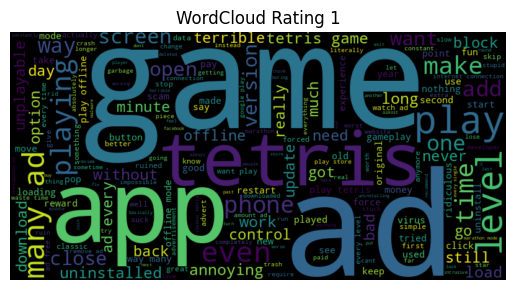

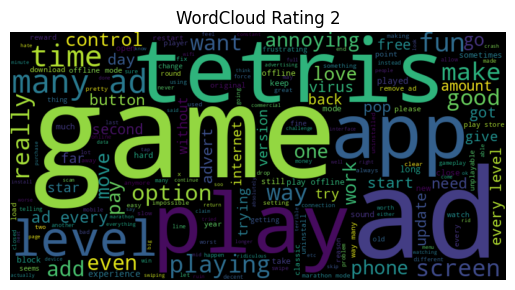

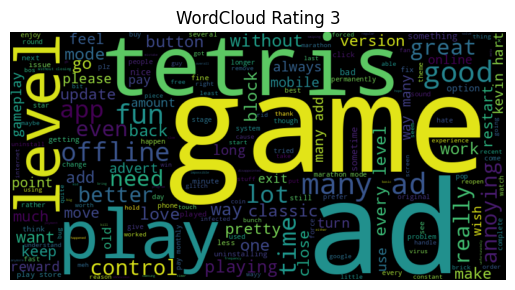

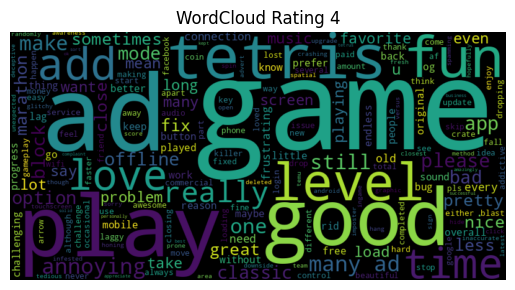

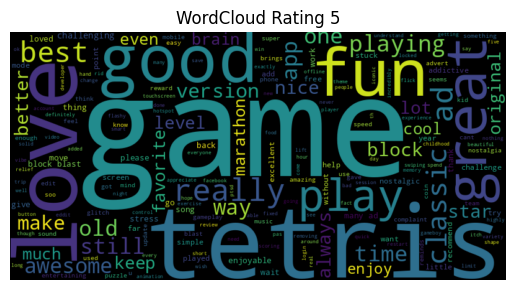

In [ ]:
from wordcloud import WordCloud

for r in sorted(df['rating'].unique()):
    text = " ".join(df[df['rating']==r]['clean'])

    wc = WordCloud(width=800, height=400).generate(text)

    plt.figure()
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud Rating {r}")
    plt.show()

Berdasarkan visualisasi WordCloud, terlihat bahwa review dengan rating rendah didominasi oleh kata-kata negatif seperti "ad", "annoying", dan "unplayable", yang menunjukkan adanya keluhan dari user. Sementara itu, rating tinggi lebih banyak mengandung kata positif seperti "love", "fun", dan "great", yang mencerminkan kepuasan user.
Namun demikian, kata "ad" tetap muncul di hampir semua rating, yang menunjukkan bahwa iklan merupakan masalah utama dalam game tetris.

### Analisis Bigram

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), max_features=10)
X = vectorizer.fit_transform(df['clean'])

print(vectorizer.get_feature_names_out())

['ad every' 'every level' 'game play' 'many ad' 'offline mode' 'play game'
 'play offline' 'play tetris' 'tetris game' 'way many']


Analisis bigram menunjukkan bahwa kombinasi kata seperti "ad every", "many ad" sering muncul, yang menunjukkan bahwa iklan merupakan keluhan utama user. Selain itu, bigram seperti "play game", "play offline", dan "play tetris" menunjukkan bahwa pengguna juga banyak membahas pengalaman bermain dan fitur aplikasi.

## No. 4

Anda memutuskan akan menggunakan machine learning unutk model prediksi,
namun sebelum itu anda perlu merepresentasikan data teks ini kedalam bentuk vektor yang dapat diterima oleh
machine learning sebagai input, maka anda menerapkan 2 bentuk metode text representation yaitu, metode yang
nilai vectornya merepresentasikan seberapa penting kata tersebut dalam suatu data sample, dan metode yang
vectornya direpresentasikan oleh kata disekitarnya yang ditraining dengan model ANN dengan input kata dan target
kata yang ada disekitarnya. Anda akan mencoba kedua metode text representation ini sebagai input yang kemudian
akan dibandingkan performance prediksinya.

### Word2Vec

Word2Vec digunakan untuk mengubah kata menjadi vektor berdasarkan konteks kata di sekitarnya, sehingga dapat menangkap makna dan hubungan antar kata.

In [ ]:
!pip install gensim

In [ ]:
tokenized = df['clean'].apply(lambda x: x.split())

In [ ]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(
    sentences=tokenized,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [ ]:
import numpy as np

def document_vector(doc):
    words = doc.split()
    vectors = [w2v_model.wv[w] for w in words if w in w2v_model.wv]

    if len(vectors) == 0:
        return np.zeros(100)

    return np.mean(vectors, axis=0)

X_w2v = np.array(df['clean'].apply(document_vector).tolist())

print(X_w2v.shape)

(2000, 100)


Representasi Word2Vec dirata-ratakan untuk menghasilkan vektor berdimensi tetap, sehingga dapat digunakan sebagai input pada model machine learning yang tidak mampu menangani data berbentuk sequence dengan panjang yang bervariasi.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_w2v = scaler.fit_transform(X_w2v)

### TF-IDF

TF-IDF digunakan untuk mengubah teks menjadi angka berdasarkan seberapa penting suatu kata dalam sebuah dokumen dibandingkan dengan dokumen lainnya.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,3),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True,
    norm='l2'
)

X_tfidf = tfidf.fit_transform(df['clean'])
y = df['rating']

print(X_tfidf.shape)

(2000, 2217)


## No. 5

Setelah text represntation selesai, anda melakukan pemodelan prediksi dengan
menggunakan 2 metode Machine Lerning yang anda pilih sendiri; tentu saja anda juga perlu melakukan tuning
hyperparameter minimal 2 hyperparameter untuk masing-masing algoritma machine learning

### Word2Vec

In [ ]:
from sklearn.model_selection import train_test_split

X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v, df['rating'],
    test_size=0.2,
    random_state=42,
    stratify=df['rating']
)

#### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_lr = {
    'C': [0.01, 0.1, 1, 5, 10, 20],
    'solver': ['liblinear', 'lbfgs']
}

grid_lr_w2v = GridSearchCV(
    LogisticRegression(max_iter=3000),
    param_lr,
    cv=3,
    scoring='f1_weighted'
)

grid_lr_w2v.fit(X_train_w2v, y_train_w2v)

best_lr_w2v = grid_lr_w2v.best_estimator_
y_pred_lr_w2v = best_lr_w2v.predict(X_test_w2v)

In [ ]:
print(grid_lr_w2v.best_estimator_)

LogisticRegression(C=20, max_iter=3000)


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test_w2v, y_pred_lr_w2v))

              precision    recall  f1-score   support

           1       0.61      0.93      0.74       220
           2       0.17      0.03      0.05        61
           3       0.20      0.03      0.05        37
           4       0.33      0.04      0.07        24
           5       0.57      0.45      0.50        58

    accuracy                           0.59       400
   macro avg       0.38      0.30      0.28       400
weighted avg       0.48      0.59      0.50       400



Dari classification report terlihat bahwa model sangat baik dalam mendeteksi rating 1 (recall tinggi 0.93),namun gagal mendeteksi kelas minoritas (2, 3, 4), serta cukup lumayan untuk rating 5 (F1 = 0.50)

#### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

param_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5]
}

grid_rf_w2v = GridSearchCV(
    RandomForestClassifier(),
    param_rf,
    cv=3,
    scoring='f1_weighted'
)

grid_rf_w2v.fit(X_train_w2v, y_train_w2v)

best_rf_w2v = grid_rf_w2v.best_estimator_
y_pred_rf_w2v = best_rf_w2v.predict(X_test_w2v)

In [ ]:
print(grid_rf_w2v.best_estimator_)

RandomForestClassifier(min_samples_split=5)


In [ ]:
print(classification_report(y_test_w2v, y_pred_rf_w2v))

              precision    recall  f1-score   support

           1       0.57      0.98      0.72       220
           2       0.00      0.00      0.00        61
           3       0.50      0.08      0.14        37
           4       0.00      0.00      0.00        24
           5       0.71      0.21      0.32        58

    accuracy                           0.57       400
   macro avg       0.36      0.25      0.24       400
weighted avg       0.46      0.57      0.46       400



Dari hasil di atas terlihat bahwa model Random Forest memprediksi rating 1 dengan sangat dominan (recall 0.98), sedangkan rating 4 tidak terdeteksi sama sekali, dan kelas lain juga sangat rendah performanya.

Dari kedua model yang menggunakan representasi Word2Vec menyebabkan hilangnya konteks penting, sehingga model kesulitan membedakan kelas dengan baik.

### TF-IDF

In [ ]:
from sklearn.model_selection import train_test_split

X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    df['clean'],
    df['rating'],
    test_size=0.2,
    random_state=42,
    stratify=df['rating']
)

In [ ]:
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,3),
    min_df=3,
    max_df=0.85,
    sublinear_tf=True,
    norm='l2'
)

X_train_tfidf = tfidf.fit_transform(X_train_tfidf)
X_test_tfidf  = tfidf.transform(X_test_tfidf)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(1600, 1815)
(400, 1815)


#### Logistic Regression

In [ ]:
param_lr = {
    'C': [0.01, 0.1, 1, 5, 10, 20],
    'solver': ['liblinear', 'lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=3000),
    param_lr,
    cv=3,
    scoring='f1_weighted'
)

grid_lr.fit(X_train_tfidf, y_train_tfidf)

best_lr_tfidf = grid_lr.best_estimator_
y_pred_lr_tfidf = best_lr_tfidf.predict(X_test_tfidf)

In [ ]:
print(grid_lr.best_estimator_)

LogisticRegression(C=5, max_iter=3000)


In [ ]:
print(classification_report(y_test_tfidf, y_pred_lr_tfidf))

              precision    recall  f1-score   support

           1       0.64      0.87      0.74       220
           2       0.14      0.07      0.09        61
           3       0.41      0.19      0.26        37
           4       0.50      0.08      0.14        24
           5       0.65      0.53      0.58        58

    accuracy                           0.59       400
   macro avg       0.47      0.35      0.36       400
weighted avg       0.53      0.59      0.54       400



Logistic Regression dari TF-IDF menghasilkan performa paling seimbang dibanding model lain, di mana rating 1 cukup baik (F1 = 0.74), dan kelas lain meskipun masih rendah tapi sudah lebih baik dari W2V.

#### Random Forest

In [ ]:
param_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(),
    param_rf,
    cv=3,
    scoring='f1_weighted'
)

grid_rf.fit(X_train_tfidf, y_train_tfidf)

best_rf = grid_rf.best_estimator_
y_pred_rf_tfidf = best_rf.predict(X_test_tfidf)

In [ ]:
print(grid_rf.best_estimator_)

RandomForestClassifier(n_estimators=300)


In [ ]:
print(classification_report(y_test_tfidf, y_pred_rf_tfidf))

              precision    recall  f1-score   support

           1       0.64      0.93      0.76       220
           2       0.20      0.02      0.03        61
           3       0.50      0.16      0.24        37
           4       0.00      0.00      0.00        24
           5       0.63      0.66      0.64        58

    accuracy                           0.62       400
   macro avg       0.39      0.35      0.34       400
weighted avg       0.52      0.62      0.54       400



Dari hasil Random Forest dengan TF-IDF menghasilkan recall rating 1 yang sangat tinggi (0.93), rating 2 memiliki recall sangat rendah, kemudian kelas 3 memiliki precision tinggi tapi recall rendah yang menandakan model jarang prediksi kelas 3. Selain itu, rating 4 hampir tidak terdeteksi, dan rating 5 cukup baik (F1 = 0.64). Dapat disimpulkan bahwa Random Forest tidak optimal untuk data TF-IDF karena kesulitan menangani data sparse.

Meskipun demikian, TF-IDF memberikan performa terbaik secara keseluruhan dengan Logistic Regression adalah model terbaik.

TF-IDF lebih efektif karena dapat mempertahankan informasi frekuensi kata yang penting dalam klasifikasi teks.

## No. 6

Anda tidak puas hanya menggunakan machine learning sebagai metode klasifikasi,
anda ingin mencoba menggunakan metode deep learning, maka anda menggunakan suatu metode deep learning
yang anda pilih sendiri dengan metode text representation yang digunakan adalah pendekatan dengan vectornya
direpresentasikan oleh kata disekitarnya yang ditraining dengan model ANN; tentu saja anda juga perlu melakukan
tuning hyperparameter minimal 2 hyperparameters.

In [ ]:
y = df['rating'] - 1

Label dikonversi dari rentang 1–5 menjadi 0–4 untuk memenuhi kebutuhan fungsi loss pada deep learning. Setelah prediksi, hasil akan dikonversi kembali ke label asli untuk keperluan evaluasi.

### Tokenization & Sequence

Sebelum memasuki pembuatan model Deep Learning, dilakukan Tokenization & Sequence terlebih dahulu untuk mengubah teks menjadi urutan indeks kata (sequence), kemudian setiap kata direpresentasikan sebagai angka berdasarkan vocabulary, dan padding dilakukan agar semua sequence memiliki panjang yang sama

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 3000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean'])

X_seq = tokenizer.texts_to_sequences(df['clean'])
X_seq = pad_sequences(X_seq, maxlen=MAX_LEN, padding='post')

### Embedding Matrix

Model deep learning menggunakan Word2Vec sebagai representasi teks karena Word2Vec mampu merepresentasikan kata berdasarkan konteks di sekitarnya melalui pendekatan neural network. Representasi ini memungkinkan model seperti LSTM untuk memanfaatkan urutan kata dalam memahami makna teks, serta CNN untuk menangkap pola lokal dalam teks secara efektif.

In [ ]:
import numpy as np

embedding_dim = 100
word_index = tokenizer.word_index

embedding_matrix = np.zeros((MAX_WORDS, embedding_dim))

for word, i in word_index.items():
    if i < MAX_WORDS and word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

### Split Data

In [ ]:
from sklearn.model_selection import train_test_split

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_seq, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Model LSTM

LSTM (Long Short-Term Memory) digunakan karena mampu menangkap hubungan urutan kata dalam teks. Model ini dirancang untuk memproses data sekuensial dan dapat mengingat informasi dari kata-kata sebelumnya, sehingga cocok untuk memahami konteks kalimat secara keseluruhan.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model_lstm = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=True
    ),
    LSTM(64),
    Dropout(0.3),
    Dense(5, activation='softmax')
])

optimizer = Adam(learning_rate=0.001, clipnorm=1.0)

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model_lstm.fit(
    X_train_dl, y_train_dl,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_dl, y_test_dl),
    callbacks=[early_stop],
    verbose=1
)

y_pred_lstm = model_lstm.predict(X_test_dl)
y_pred_lstm = y_pred_lstm.argmax(axis=1)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.5469 - loss: 1.3456 - val_accuracy: 0.5500 - val_loss: 1.2887
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5500 - loss: 1.2986 - val_accuracy: 0.5500 - val_loss: 1.2894
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5500 - loss: 1.2990 - val_accuracy: 0.5500 - val_loss: 1.2858
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5500 - loss: 1.3029 - val_accuracy: 0.5500 - val_loss: 1.2858
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5500 - loss: 1.2971 - val_accuracy: 0.5500 - val_loss: 1.2893
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [ ]:
print(classification_report(y_test_dl, y_pred_lstm))

              precision    recall  f1-score   support

           0       0.55      1.00      0.71       220
           1       0.00      0.00      0.00        61
           2       0.00      0.00      0.00        37
           3       0.00      0.00      0.00        24
           4       0.00      0.00      0.00        58

    accuracy                           0.55       400
   macro avg       0.11      0.20      0.14       400
weighted avg       0.30      0.55      0.39       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Dari hasil model LSTM terlihat bahwa model mengalami mode collapse, yaitu hanya memprediksi satu kelas dominan (kelas 0) tanpa mampu membedakan kelas lainnya. LSTM gagal mempelajari pola data dengan baik dan cenderung bias terhadap kelas mayoritas, sehingga performanya sangat tidak seimbang.

### Model CNN

CNN digunakan karena mampu menangkap pola lokal dalam teks, seperti kombinasi kata atau frasa tertentu. Dengan menggunakan operasi konvolusi, CNN dapat mengekstraksi fitur penting dari teks secara efisien.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

model_cnn = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=True
    ),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

model_cnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

history_cnn = model_cnn.fit(
    X_train_dl, y_train_dl,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_dl, y_test_dl),
    verbose=1
)

y_pred_cnn = model_cnn.predict(X_test_dl)
y_pred_cnn = y_pred_cnn.argmax(axis=1)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - accuracy: 0.5412 - loss: 1.3104 - val_accuracy: 0.5500 - val_loss: 1.2639
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5519 - loss: 1.2799 - val_accuracy: 0.5500 - val_loss: 1.2574
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5544 - loss: 1.2497 - val_accuracy: 0.5500 - val_loss: 1.2331
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5619 - loss: 1.2105 - val_accuracy: 0.6025 - val_loss: 1.1895
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6056 - loss: 1.1268 - val_accuracy: 0.6100 - val_loss: 1.1374
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6444 - loss: 1.0151 - val_accuracy: 0.6150 - val_loss: 1.0811
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6794 - loss: 0.8743 - val_accuracy: 0.5925 - val_loss: 1.0492
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7231 - loss: 0.7523 - val_accuracy: 0.5950 - val_loss

In [ ]:
print(classification_report(y_test_dl, y_pred_cnn))

              precision    recall  f1-score   support

           0       0.67      0.87      0.76       220
           1       0.25      0.10      0.14        61
           2       0.17      0.11      0.13        37
           3       0.00      0.00      0.00        24
           4       0.66      0.76      0.70        58

    accuracy                           0.61       400
   macro avg       0.35      0.37      0.35       400
weighted avg       0.52      0.61      0.55       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


CNN memberikan performa yang cukup baik dan lebih seimbang dibandingkan LSTM, meskipun masih kesulitan dalam mendeteksi beberapa kelas minoritas seperti kelas 3 yang tidak terdeteksi sama sekali.

Secara keseluruhan, CNN menunjukkan performa yang lebih baik dibandingkan LSTM, namun kedua model deep learning masih belum mampu mengungguli model machine learning karena keterbatasan jumlah data dan karakteristik teks yang sederhana.

## No. 7

Untuk mengetahui performa model prediksi yang anda kerjakan, tentu anda perlu
melakukan performance evaluation dan juga menganalisa hasilnya. Anda melakukan perbandingan performance
test data dari model yang dibuat dengan metode text representation yang berbeda, dan anda membuat summary
hasil sebagai berikut:

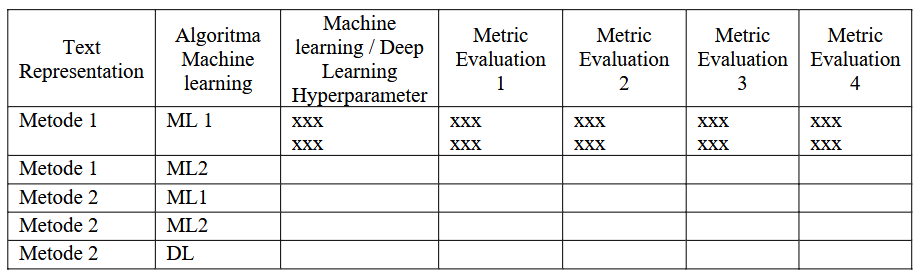

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def get_metrics(y_true, y_pred):
    return (
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='weighted', zero_division=0),
        recall_score(y_true, y_pred, average='weighted', zero_division=0),
        f1_score(y_true, y_pred, average='weighted', zero_division=0)
    )

In [ ]:
results = []

# TF-IDF
results.append(["TF-IDF","LR"] + list(get_metrics(y_test_tfidf, y_pred_lr_tfidf)))
results.append(["TF-IDF","RF"] + list(get_metrics(y_test_tfidf, y_pred_rf_tfidf)))

# Word2Vec
results.append(["W2V","LR"] + list(get_metrics(y_test_w2v, y_pred_lr_w2v)))
results.append(["W2V","RF"] + list(get_metrics(y_test_w2v, y_pred_rf_w2v)))

# Deep Learning
results.append(["W2V","LSTM"] + list(get_metrics(y_test_dl, y_pred_lstm)))
results.append(["W2V","CNN"] + list(get_metrics(y_test_dl, y_pred_cnn)))

In [ ]:
import pandas as pd

df_result = pd.DataFrame(results, columns=[
    "TextRep","Model","Accuracy","Precision","Recall","F1"
])

print(df_result)

  TextRep Model  Accuracy  Precision  Recall        F1
0  TF-IDF    LR    0.5900   0.532437  0.5900  0.535517
1  TF-IDF    RF    0.6250   0.518739  0.6250  0.536716
2     W2V    LR    0.5875   0.483448  0.5875  0.496745
3     W2V    RF    0.5750   0.464779  0.5750  0.457455
4     W2V  LSTM    0.5500   0.302500  0.5500  0.390323
5     W2V   CNN    0.6150   0.518667  0.6150  0.553334


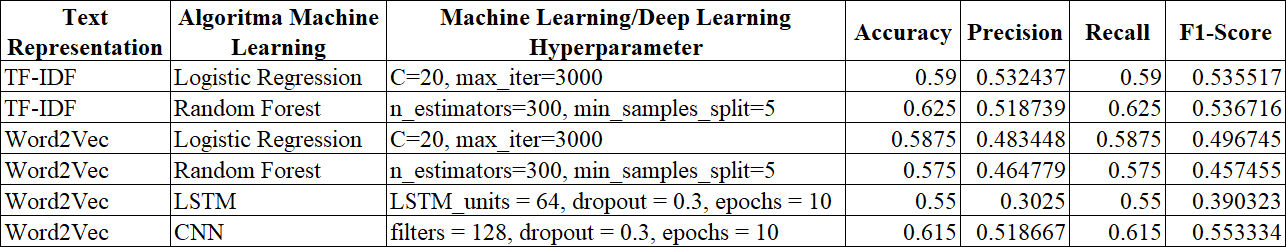

Berdasarkan hasil evaluasi, model terbaik adalah TF-IDF dengan Logistic Regression dan Random Forest. Model deep learning, khususnya LSTM, tidak mampu memberikan performa yang baik dan mengalami bias terhadap kelas mayoritas. CNN menunjukkan performa yang lebih baik dibandingkan LSTM, namun masih belum mengungguli model machine learning. Hal ini menunjukkan bahwa pada dataset dengan ukuran terbatas dan teks pendek, model machine learning lebih efektif dibandingkan deep learning.

In [ ]:
# jika hanya menggunakan 1 model DL (sesuai tabel di soal)
results = []

# TF-IDF
results.append(["TF-IDF","LR"] + list(get_metrics(y_test_tfidf, y_pred_lr_tfidf)))
results.append(["TF-IDF","RF"] + list(get_metrics(y_test_tfidf, y_pred_rf_tfidf)))

# Word2Vec
results.append(["W2V","LR"] + list(get_metrics(y_test_w2v, y_pred_lr_w2v)))
results.append(["W2V","RF"] + list(get_metrics(y_test_w2v, y_pred_rf_w2v)))

# Deep Learning
results.append(["W2V","CNN"] + list(get_metrics(y_test_dl, y_pred_cnn)))
df_result = pd.DataFrame(results, columns=[
    "TextRep","Model","Accuracy","Precision","Recall","F1"
])

print(df_result)

  TextRep Model  Accuracy  Precision  Recall        F1
0  TF-IDF    LR    0.5900   0.532437  0.5900  0.535517
1  TF-IDF    RF    0.6250   0.518739  0.6250  0.536716
2     W2V    LR    0.5875   0.483448  0.5875  0.496745
3     W2V    RF    0.5750   0.464779  0.5750  0.457455
4     W2V   CNN    0.6150   0.518667  0.6150  0.553334


## No. 8

Anda mendapati ternyata data anda imbalance, sehingga anda penasaran, apakah
jika kondisi imbalance data ini dihandle, akan ada perubahan pada perfomance atau tidak, sehingga anda
melakukan treatment terhadap data imbalance dan melakukan training kembali dan melakukan evaluasi terhadap
model dengan kondisi data baru. Anda membandingkan evaluasi performancenya dan mendapatkan kesimpulan,
model mana yang terbaik.

In [ ]:
!pip install imbalanced-learn

### SMOTE untuk Model Machine Learning

Penerapan teknik SMOTE pada model machine learning dilakukan untuk mengatasi ketidakseimbangan data dengan menambahkan sampel sintetis pada kelas minoritas.

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#### Word2Vec

In [ ]:
X_train_w2v_spl, X_test_w2v_spl, y_train_w2v_spl, y_test_w2v_spl = train_test_split(
    X_w2v, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

sm = SMOTE(random_state=42)
X_train_w2v_sm, y_train_w2v_sm = sm.fit_resample(X_train_w2v_spl, y_train_w2v_spl)

##### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_lr = {
    'C': [0.01, 0.1, 1, 5, 10],
    'solver': ['liblinear']
}

grid_lr_w2v_s = GridSearchCV(
    LogisticRegression(max_iter=3000),
    param_lr,
    cv=3,
    scoring='f1_weighted'
)

grid_lr_w2v_s.fit(X_train_w2v_sm, y_train_w2v_sm)
best_lr_w2v_s = grid_lr_w2v_s.best_estimator_
y_pred_lr_w2v_s = best_lr_w2v_s.predict(X_test_w2v_spl)

print(classification_report(y_test_w2v_spl, y_pred_lr_w2v_s))

              precision    recall  f1-score   support

           1       0.72      0.40      0.51       220
           2       0.18      0.25      0.21        61
           3       0.18      0.38      0.24        37
           4       0.14      0.25      0.18        24
           5       0.48      0.60      0.53        58

    accuracy                           0.40       400
   macro avg       0.34      0.38      0.34       400
weighted avg       0.52      0.40      0.42       400



##### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

grid_rf_w2v_s = GridSearchCV(
    RandomForestClassifier(),
    param_rf,
    cv=3,
    scoring='f1_weighted'
)

grid_rf_w2v_s.fit(X_train_w2v_sm, y_train_w2v_sm)
best_rf_w2v_s = grid_rf_w2v_s.best_estimator_
y_pred_rf_w2v_s = best_rf_w2v_s.predict(X_test_w2v_spl)

print(classification_report(y_test_w2v_spl, y_pred_rf_w2v_s))

              precision    recall  f1-score   support

           1       0.63      0.73      0.68       220
           2       0.21      0.15      0.17        61
           3       0.22      0.19      0.20        37
           4       0.14      0.12      0.13        24
           5       0.57      0.50      0.53        58

    accuracy                           0.52       400
   macro avg       0.35      0.34      0.34       400
weighted avg       0.49      0.52      0.50       400



Pada Word2Vec, penerapan SMOTE tidak memberikan peningkatan performa yang signifikan. Logistic Regression mengalami penurunan performa, sementara Random Forest sedikit meningkat, namun masih belum optimal. Hal ini menunjukkan bahwa data sintetis yang dihasilkan oleh SMOTE tidak mampu merepresentasikan karakteristik vektor Word2Vec dengan baik.

#### TF-IDF

In [ ]:
X_train_tfidf_spl, X_test_tfidf_spl, y_train_tfidf_spl, y_test_tfidf_spl = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

sm = SMOTE(random_state=42)
X_train_tfidf_sm, y_train_tfidf_sm = sm.fit_resample(X_train_tfidf_spl, y_train_tfidf_spl)

##### Logistic Regression

In [ ]:
param_lr = {
    'C': [0.01, 0.1, 1, 5, 10],
    'solver': ['liblinear']
}

grid_lr_tfidf_s = GridSearchCV(
    LogisticRegression(max_iter=3000),
    param_lr,
    cv=3,
    scoring='f1_weighted'
)

grid_lr_tfidf_s.fit(X_train_tfidf_sm, y_train_tfidf_sm)
best_lr_tfidf_s = grid_lr_tfidf_s.best_estimator_
y_pred_lr_tfidf_s = best_lr_tfidf_s.predict(X_test_tfidf_spl)

print(classification_report(y_test_tfidf_spl, y_pred_lr_tfidf_s))

              precision    recall  f1-score   support

           1       0.76      0.67      0.71       220
           2       0.18      0.20      0.19        61
           3       0.25      0.38      0.30        37
           4       0.24      0.29      0.26        24
           5       0.71      0.62      0.66        58

    accuracy                           0.54       400
   macro avg       0.43      0.43      0.42       400
weighted avg       0.58      0.54      0.56       400



##### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

param_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5]
}

grid_rf_tfidf_s = GridSearchCV(
    RandomForestClassifier(),
    param_rf,
    cv=3,
    scoring='f1_weighted'
)

grid_rf_tfidf_s.fit(X_train_tfidf_sm, y_train_tfidf_sm)
best_rf_tfidf_s = grid_rf_tfidf_s.best_estimator_
y_pred_rf_tfidf_s = best_rf_tfidf_s.predict(X_test_tfidf_spl)

print(classification_report(y_test_tfidf_spl, y_pred_rf_tfidf_s))

              precision    recall  f1-score   support

           1       0.70      0.63      0.66       220
           2       0.20      0.15      0.17        61
           3       0.26      0.24      0.25        37
           4       0.25      0.04      0.07        24
           5       0.38      0.78      0.51        58

    accuracy                           0.51       400
   macro avg       0.36      0.37      0.33       400
weighted avg       0.51      0.51      0.49       400



Pada TF-IDF, penerapan SMOTE memberikan hasil yang lebih stabil dibandingkan Word2Vec. Logistic Regression menunjukkan performa yang cukup baik dengan peningkatan keseimbangan antar kelas, meskipun tidak terjadi peningkatan yang signifikan dibandingkan sebelum balancing.

### Class Weight untuk Model Deep Learning

Untuk model deep learning, penanganan imbalance dilakukan menggunakan class weight yang memberikan bobot lebih besar pada kelas minoritas.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_dl),
    y=y_train_dl
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.36363636363636365), 1: np.float64(1.316872427983539), 2: np.float64(2.119205298013245), 3: np.float64(3.404255319148936), 4: np.float64(1.3793103448275863)}


#### LSTM

In [ ]:
model_bal_lstm = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=True
    ),
    LSTM(64),
    Dropout(0.3),
    Dense(5, activation='softmax')
])

model_bal_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001, clipnorm=1.0),
    metrics=['accuracy']
)

history_bal_lstm = model_bal_lstm.fit(
    X_train_dl, y_train_dl,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_dl, y_test_dl),
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.1231 - loss: 1.6141 - val_accuracy: 0.1525 - val_loss: 1.6065
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1594 - loss: 1.6116 - val_accuracy: 0.5500 - val_loss: 1.6030
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2306 - loss: 1.6114 - val_accuracy: 0.0600 - val_loss: 1.6173
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1106 - loss: 1.6113 - val_accuracy: 0.1450 - val_loss: 1.6007
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1281 - loss: 1.6121 - val_accuracy: 0.0925 - val_loss: 1.6106
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.1281 - loss: 1.6113 - val_accuracy: 0.1525 - val_loss: 1.6139
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2369 - loss: 1.6119 - val_accuracy: 0.0600 - val_loss: 1.6129
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1094 - loss: 1.6112 - val_accuracy: 0.1450 - v

In [ ]:
print(classification_report(y_test_dl, y_pred_lstm_after))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       220
           1       0.00      0.00      0.00        61
           2       0.00      0.00      0.00        37
           3       0.00      0.00      0.00        24
           4       0.14      1.00      0.25        58

    accuracy                           0.14       400
   macro avg       0.03      0.20      0.05       400
weighted avg       0.02      0.14      0.04       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Penerapan class weight pada LSTM tidak berhasil meningkatkan performa model. Model tetap mengalami bias ekstrem terhadap satu kelas dan gagal mempelajari distribusi data secara seimbang. Hal ini menunjukkan bahwa LSTM membutuhkan data yang lebih besar dan kompleks agar dapat bekerja dengan optimal.

#### CNN

In [ ]:
model_bal_cnn = Sequential([
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=True
    ),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(5, activation='softmax')
])

model_bal_cnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

history_bal_cnn = model_bal_cnn.fit(
    X_train_dl, y_train_dl,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_dl, y_test_dl),
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.2431 - loss: 1.6199 - val_accuracy: 0.2925 - val_loss: 1.5677
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2625 - loss: 1.5789 - val_accuracy: 0.4475 - val_loss: 1.5041
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2956 - loss: 1.5660 - val_accuracy: 0.3775 - val_loss: 1.4988
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2894 - loss: 1.5144 - val_accuracy: 0.4300 - val_loss: 1.5129
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3963 - loss: 1.4365 - val_accuracy: 0.2200 - val_loss: 1.4858
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3475 - loss: 1.3623 - val_accuracy: 0.2900 - val_loss: 1.3813
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3963 - loss: 1.2941 - val_accuracy: 0.3575 - val_loss: 1.3290
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4675 - loss: 1.1920 - val_accuracy: 0.4525 - val_loss

In [ ]:
print(classification_report(y_test_dl, y_pred_cnn_after))

              precision    recall  f1-score   support

           0       0.74      0.62      0.67       220
           1       0.18      0.15      0.16        61
           2       0.18      0.32      0.24        37
           3       0.12      0.25      0.16        24
           4       0.73      0.66      0.69        58

    accuracy                           0.50       400
   macro avg       0.39      0.40      0.39       400
weighted avg       0.57      0.50      0.53       400



CNN menunjukkan performa yang lebih stabil dibandingkan LSTM setelah penerapan class weight. Model mampu mengenali beberapa kelas dengan lebih baik, meskipun masih terdapat ketidakseimbangan dalam prediksi. Hal ini menunjukkan bahwa CNN lebih robust terhadap data imbalance dibandingkan LSTM.

In [ ]:
# BEFORE
y_pred_lstm_before = model_lstm.predict(X_test_dl)
y_pred_lstm_before = y_pred_lstm_before.argmax(axis=1)
y_pred_cnn_before = model_cnn.predict(X_test_dl)
y_pred_cnn_before = y_pred_cnn_before.argmax(axis=1)

# AFTER
y_pred_lstm_after = model_bal_lstm.predict(X_test_dl)
y_pred_lstm_after = y_pred_lstm_after.argmax(axis=1)
y_pred_cnn_after = model_bal_cnn.predict(X_test_dl)
y_pred_cnn_after = y_pred_cnn_after.argmax(axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


### Final Table

In [ ]:
results_full = []

# ===== BEFORE =====
results_full.append(["TFIDF","LR","BEFORE"] + list(get_metrics(y_test_tfidf, y_pred_lr_tfidf)))
results_full.append(["TFIDF","RF","BEFORE"] + list(get_metrics(y_test_tfidf, y_pred_rf_tfidf)))
results_full.append(["W2V","LR","BEFORE"] + list(get_metrics(y_test_w2v, y_pred_lr_w2v)))
results_full.append(["W2V","RF","BEFORE"] + list(get_metrics(y_test_w2v, y_pred_rf_w2v)))
results_full.append(["W2V","LSTM","BEFORE"] + list(get_metrics(y_test_dl, y_pred_lstm_before)))
results_full.append(["W2V","CNN","BEFORE"] + list(get_metrics(y_test_dl, y_pred_cnn_before)))

# ===== AFTER SMOTE =====
results_full.append(["TFIDF","LR","SMOTE"] + list(get_metrics(y_test_tfidf, y_pred_lr_tfidf_s)))
results_full.append(["TFIDF","RF","SMOTE"] + list(get_metrics(y_test_tfidf, y_pred_rf_tfidf_s)))
results_full.append(["W2V","LR","SMOTE"] + list(get_metrics(y_test_w2v_spl, y_pred_lr_w2v_s)))
results_full.append(["W2V","RF","SMOTE"] + list(get_metrics(y_test_w2v_spl, y_pred_rf_w2v_s)))

# ===== DL WEIGHTED =====
results_full.append(["W2V","LSTM","WEIGHTED"] + list(get_metrics(y_test_dl, y_pred_lstm_after)))
results_full.append(["W2V","CNN","WEIGHTED"] + list(get_metrics(y_test_dl, y_pred_cnn_after)))

df_full = pd.DataFrame(results_full, columns=[
    "TextRep","Model","Condition","Accuracy","Precision","Recall","F1"
])

print(df_full)

   TextRep Model Condition  Accuracy  Precision  Recall        F1
0    TFIDF    LR    BEFORE    0.5900   0.532437  0.5900  0.535517
1    TFIDF    RF    BEFORE    0.6250   0.518739  0.6250  0.536716
2      W2V    LR    BEFORE    0.5875   0.483448  0.5875  0.496745
3      W2V    RF    BEFORE    0.5750   0.464779  0.5750  0.457455
4      W2V  LSTM    BEFORE    0.5500   0.302500  0.5500  0.390323
5      W2V   CNN    BEFORE    0.6150   0.518667  0.6150  0.553334
6    TFIDF    LR     SMOTE    0.5425   0.583903  0.5425  0.559843
7    TFIDF    RF     SMOTE    0.5050   0.509198  0.5050  0.491241
8      W2V    LR     SMOTE    0.3950   0.515541  0.3950  0.424704
9      W2V    RF     SMOTE    0.5200   0.491372  0.5200  0.502494
10     W2V  LSTM  WEIGHTED    0.1450   0.021025  0.1450  0.036725
11     W2V   CNN  WEIGHTED    0.5025   0.566040  0.5025  0.527534


Berdasarkan perbandingan, terlihat bahwa teknik balancing seperti SMOTE dan class weight tidak selalu meningkatkan performa model. Pada beberapa kasus, performa model justru menurun setelah dilakukan balancing. Hal ini menunjukkan bahwa teknik balancing harus digunakan secara hati-hati dan disesuaikan dengan karakteristik data dan model.

Secara keseluruhan, model berbasis TF-IDF dengan Logistic Regression dan Random Forest tetap memberikan performa yang paling stabil dan konsisten. Meskipun CNN menunjukkan performa yang cukup kompetitif, model deep learning belum mampu mengungguli machine learning. Word2Vec cenderung memiliki performa lebih rendah pada machine learning karena kehilangan informasi saat proses averaging, sementara LSTM menunjukkan performa terendah akibat ketidakmampuan dalam menangani data yang terbatas dan tidak seimbang.